# Simulating a Lensed Galaxy Datacube

This notebook demonstrates how to simulate a 3D IFU datacube of a gravitationally lensed galaxy using the `iful` package. The simulation parameters are configured to match the **JWST NIRSpec G235M** instrument specifications:
1. **Field of View (FOV)**: We use a spatial grid of $30 \times 30$ pixels with a pixel scale of $0.075$ arcsec/pixel, yielding a $3.0" \times 3.0"$ FOV that perfectly matches the physical field of view of the NIRSpec IFU.
2. **Gravitational Lensing**: We set up a cusp lensing configuration with an Elliptical Power-Law (`EPL_Q_PHI`) lens plus external shear (`SHEAR`). The Einstein radius is set to $\theta_E = 0.8"$, ensuring the entire lensed structure fits within the $3" \times 3"$ FOV.
3. **Source Plane Kinematics**: We model the source plane using:
   - An arctan rotation curve (`ARCTAN`).
   - A constant velocity dispersion + central supermassive black hole component (`CONSTANT_FITTED_BH`).
   - An elliptical Sersic profile (`SERSIC`) for the surface brightness.
4. **Spectral Resolution & Wavelength Range**: We use a spectral resolution $R = 1000$ and a wavelength range of 23650 Å to 24250 Å (23700 Å to 24200 Å after continuum subtraction) with a dispersion of 10 Å/channel. This fully encapsulates both the [OIII] 4959Å and 5007Å emission doublet lines for a source galaxy at redshift $z=3.8$ without any clipping.
5. **Noise simulation**: We simulate realistic instrumental noise by adding Gaussian background/readout noise and Poisson-like shot noise to the final lensed datacube before saving it as a FITS file.

In [1]:
import sys
import os
import copy
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.io.fits import Header
from astropy.wcs import WCS
import astropy.units as u
from astropy.cosmology import FlatLambdaCDM

# Adjust path to import iful package from the src directory
sys.path.append("../src")
from iful.image_set import ImageSet
from iful.flat_modeling import FlatModel
from iful.iful_modeling import IFULModel
from iful.util import *

# Monkeypatch lenstronomy to support '_imageModel_list' attribute for backward compatibility
import lenstronomy.ImSim.MultiBand.multi_linear as ml
ml.MultiLinear._imageModel_list = property(lambda self: self._image_model_list)

print("Libraries imported and monkeypatched successfully!")

Libraries imported and monkeypatched successfully!


/home/william-sheu/Documents/iful/examples/../src/iful/iful_modeling.py:11: UserWarning: ⚠️ VorBin is deprecated and superseded by PowerBin https://pypi.org/project/powerbin/ 
  from vorbin.voronoi_2d_binning import voronoi_2d_binning


## 1. Setup Mock ImageSet with JWST NIRSpec WCS

We set up a mock `ImageSet` object. At $z = 3.8$, the [OIII] 4959Å & 5007Å doublet lines are observed at:
$$\lambda_{\text{obs, 4959}} = 4959 \times (1 + z) = 23803.2\text{ Å}$$
$$\lambda_{\text{obs, 5007}} = 5007 \times (1 + z) = 24033.6\text{ Å}$$

We define a wavelength grid around these lines (from 23650 Å to 24250 Å). To allow lenstronomy's Sersic linear solvers to fit correctly, we initialize `self.datacube` and `self.datacube_whitelight` to positive non-zero values. The pixel scale is specified in degrees (`0.1 / 3600.0` degrees per pixel) to match WCS projection scaling.

In [2]:
wavelengths = np.linspace(23650.0-300, 24250.0+300, 120)

class MockImageSet(ImageSet):
    def __init__(self):
        self.zs = 3.8
        self.size = 40
        self.pixscale = 0.075 / 3600.0  # Pixel scale in degrees/pixel (0.1 arcsec/pixel)
        
        # 60 wavelength bins; after continuum subtraction, we will have 50 wavelength bins
        wavelengths = np.linspace(23650.0-300, 24250.0+300, 120)
        datacube = np.zeros((40, 40, 120))
        
        self.continuum_subtraction(datacube, wavelengths, 0, 5)
        
        # Overwrite datacubes with positive values to avoid all-zero fits
        self.datacube = np.ones((40, 40, 110)) * 10.0
        self.datacube_whitelight = np.ones((40, 40)) * 10.0
        
        self.brms_3d = 0.01
        self.brms_2d = 0.01
        
        # Mock 3D WCS Header for the datacube (RA, DEC, wavelength)
        header_wcs = Header()
        header_wcs["CTYPE1"] = "RA---TAN"
        header_wcs["CTYPE2"] = "DEC--TAN"
        header_wcs["CTYPE3"] = "AWAV"
        header_wcs["CRPIX1"] = 20.5
        header_wcs["CRVAL1"] = 0.0
        header_wcs["CDELT1"] = -0.075 / 3600.0
        header_wcs["CUNIT1"] = "deg"
        header_wcs["CRPIX2"] = 20.5
        header_wcs["CRVAL2"] = 0.0
        header_wcs["CDELT2"] = 0.075 / 3600.0
        header_wcs["CUNIT2"] = "deg"
        header_wcs["CRPIX3"] = 1.0
        header_wcs["CRVAL3"] = wavelengths[5]
        header_wcs["CDELT3"] = 10.0
        header_wcs["CUNIT3"] = "Angstrom"
        
        self.aux_info = {
            "header_wcs": header_wcs,
            "init_lens_center": np.array([[19.5, 19.5]]),
            "pixscale": 0.075 / 3600.0,
            "exptime": 1000.0,
            "final_psf": np.load("example_data/nirspec_g235m_psf.npy")
        }
        self.img_locations = np.array([])

# Set up restwave peaks for both [OIII] 4959 and 5007 lines
restwave_peaks = [4959.0, 5007.0]

imset = MockImageSet()
imset.restwave_peaks = restwave_peaks
# parameters format: [z, sigma_ang, amp_0, ratio (5007/4959 = 3.0)]
imset.init_spec_fit = np.array([3.8, 24.0, 1.0, 3.0])


## 2. Setup FlatModel & Lenstronomy Parameters

We initialize a `FlatModel` using an Elliptical Power-Law (`EPL_Q_PHI`) lens, external shear (`SHEAR`), and an elliptical Sersic (`SERSIC_ELLIPSE`) source light profile. The Einstein radius is set to $\theta_E = 0.8"$ to ensure it fits within the NIRSpec field of view.

In [3]:
from lenstronomy.Workflow.fitting_sequence import FittingSequence

shift_x = -0.5
shift_y = 0.3

# Define FlatModel
fm = FlatModel(imset, ["EPL_Q_PHI", "SHEAR"], ["SERSIC_ELLIPSE"])

# Define lenstronomy parameters
kwargs_model = {
    "lens_model_list": ["EPL_Q_PHI", "SHEAR"],
    "source_light_model_list": ["SERSIC_ELLIPSE"],
    "lens_light_model_list": [],
    "point_source_model_list": [],
    "fixed_magnification_list": [],
}

kwargs_data_joint = {
    "multi_band_list": [fm.multi_band_list],
    "multi_band_type": "single-band",
}

# Ground-truth values for simulation
kwargs_lens_init = [
    {"theta_E": 1, "gamma": 1.8, "q": 0.75, "phi": 0.5, "center_x": 0.0+shift_x, "center_y": 0.0+shift_y},
    {"gamma1": 0.05, "gamma2": -0.05, "ra_0": 0.0, "dec_0": 0.0}
]
kwargs_lens_sigma = [
    {"theta_E": 0.05, "gamma": 0.05, "q": 0.02, "phi": 0.05, "center_x": 0.05, "center_y": 0.05},
    {"gamma1": 0.005, "gamma2": 0.005, "ra_0": 0.05, "dec_0": 0.05}
]
fixed_lens = [{}, {"ra_0": 0.0, "dec_0": 0.0}]
kwargs_lower_lens = [
    {"theta_E": 0.2, "gamma": 1.5, "q": 0.3, "phi": -np.pi, "center_x": -1.0, "center_y": -1.0},
    {"gamma1": -0.2, "gamma2": -0.2}
]
kwargs_upper_lens = [
    {"theta_E": 1.5, "gamma": 2.5, "q": 1.0, "phi": np.pi, "center_x": 1.0, "center_y": 1.0},
    {"gamma1": 0.2, "gamma2": 0.2}
]

kwargs_source_init = [{"amp": 1000.0, "R_sersic": 0.075, "n_sersic": 1.5, "e1": 0.0, "e2": 0.0, "center_x": 0.09+shift_x, "center_y": 0.09+shift_y}]
kwargs_source_sigma = [{"amp": 100.0, "R_sersic": 0.02, "n_sersic": 0.1, "e1": 0.05, "e2": 0.05, "center_x": 0.05, "center_y": 0.05}]
fixed_source = [{}]
kwargs_lower_source = [{"amp": 0.0, "R_sersic": 0.005, "n_sersic": 0.5, "e1": -0.5, "e2": -0.5, "center_x": -1.0, "center_y": -1.0}]
kwargs_upper_source = [{"amp": 1e6, "R_sersic": 1.0, "n_sersic": 8.0, "e1": 0.5, "e2": 0.5, "center_x": 1.0, "center_y": 1.0}]

kwargs_params = {
    "lens_model": [kwargs_lens_init, kwargs_lens_sigma, fixed_lens, kwargs_lower_lens, kwargs_upper_lens],
    "source_model": [kwargs_source_init, kwargs_source_sigma, fixed_source, kwargs_lower_source, kwargs_upper_source],
    "lens_light_model": [[], [], [], [], []],
    "point_source_model": [[], [], [], [], []],
}

fitting_seq = FittingSequence(
    kwargs_data_joint,
    kwargs_model,
    {},
    {},
    kwargs_params,
)

fm.init_fitting_seq = fitting_seq
fm.init_pso_fit = {
    "kwargs_lens": kwargs_lens_init,
    "kwargs_source": kwargs_source_init,
}
print("FlatModel configured successfully!")

FlatModel configured successfully!


## 3. Instantiate IFULModel

We set up our 3D kinematic model (`IFULModel`) using the profiles:
- **v_los**: `"ARCTAN"` (arctan rotation curve, 4 parameters)
- **v_disp**: `"CONSTANT_FITTED_BH"` (constant velocity dispersion + point-like supermassive black hole component, 2 parameters)
- **flx**: `"SERSIC"` (surface brightness scaling, 1 parameter)

In [4]:
iful_profiles = ["ARCTAN", "CONSTANT_FITTED_BH", "SERSIC"]
d_s = FlatLambdaCDM(H0=70, Om0=0.3).angular_diameter_distance(imset.zs).to(u.kpc).value

ifulmodel = IFULModel(
    imset, fm, iful_profiles,
    sourceplane_size=100, num_bins=0, num_rsersics=1,
    spectral_res=1000, equal_weight_voronoi=False, d_s=d_s
)
print("IFULModel instantiated successfully!")

IFULModel instantiated successfully!


## 4. Visualize Lensing Configuration (Cusp Configuration)

We place the Sersic source near the cusp of the caustic ($x = 0.09$, $y = 0.09$ arcsec) in the source plane. This creates a classic **cusp lensing configuration** with three merged images on one side of the lens (spanning the top and right parts of the critical curve) and a fourth image on the opposite side (bottom-left). All structures fit within the physical 3.0" x 3.0" field of view.

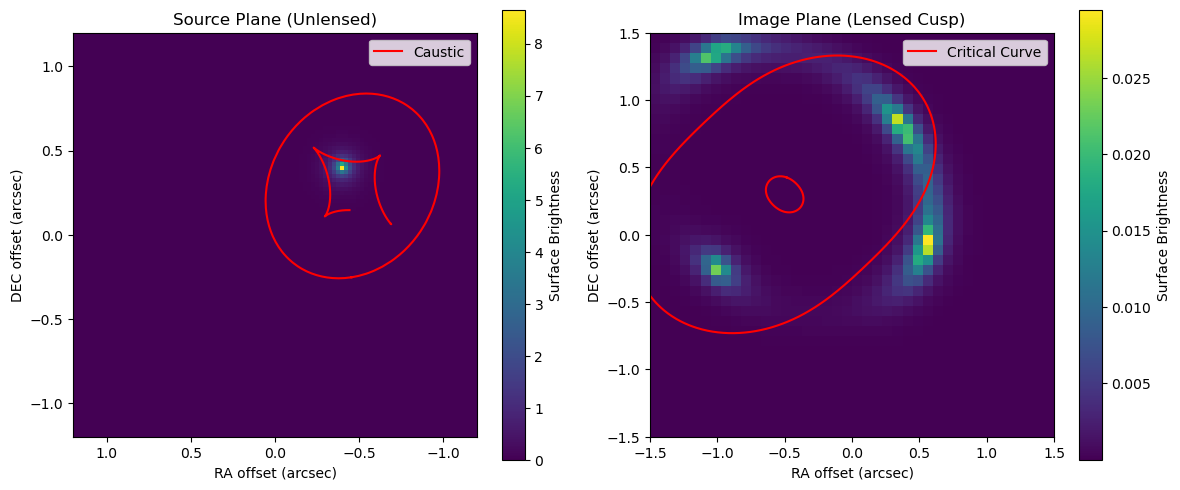

In [5]:
from lenstronomy.LensModel.lens_model import LensModel
from lenstronomy.LensModel.lens_model_extensions import LensModelExtensions

# Extract parameters
c = 299792
sim_params = [
    # EPL_Q_PHI (6 params): theta_E, gamma, q, phi, center_x, center_y
    1., 1.8, 0.75, 0.5, 0.0+shift_x, 0.0+shift_y,
    # SHEAR (2 params): gamma1, gamma2
    0.05, -0.05,
    # Source (6 params): R_sersic, n_sersic, e1, e2, center_x, center_y
    0.075, 1.5, 0.0, 0.0, 0.09+shift_x, 0.09+shift_y,
    # v_los (4 params): v_pa, v_a, v_b, v_c (sys_vel = zs * c)
    -45.0, 300.0, 15, 3.8 * c,
    # v_disp (2 params): constant velocity dispersion of 150 km/s and log10 BH mass of 9.0
    50.0, 9.0,
    # flx (1 param): scale factor
    1e6
]

lens_model_params = sim_params[: ifulmodel.len_model_numparams]
kwargs_lenstronomy = ifulmodel.init_fitting_seq.param_class.args2kwargs(lens_model_params)
immodel = ifulmodel.immodel_init._imageModel_list[0]

# Calculate critical curves and caustics
lens_model = LensModel(lens_model_list=["EPL_Q_PHI", "SHEAR"])
lens_model_ext = LensModelExtensions(lens_model)
ra_crit, dec_crit, ra_caustic, dec_caustic = lens_model_ext.critical_curve_caustics(
    kwargs_lenstronomy["kwargs_lens"], compute_window=3, grid_scale=0.01
)

# Evaluate unlensed source plane surface brightness
x_grid_source, y_grid_source = np.meshgrid(
    (np.arange(100) - 50) * 0.024,
    (np.arange(100) - 50) * 0.024
)
unlensed_source = ifulmodel.sm_init._light_model.surface_brightness(
    x_grid_source, y_grid_source, kwargs_lenstronomy["kwargs_source"]
)

# Evaluate lensed image
lensed_image = immodel.image(
    kwargs_lenstronomy["kwargs_lens"],
    kwargs_lenstronomy["kwargs_source"]
)

# Plotting
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Source plane
im1 = axs[0].imshow(unlensed_source, extent=[-1.2, 1.2, -1.2, 1.2], origin='lower', cmap='viridis')
axs[0].set_title("Source Plane (Unlensed)")
axs[0].set_xlabel("RA offset (arcsec)")
axs[0].set_ylabel("DEC offset (arcsec)")
fig.colorbar(im1, ax=axs[0], label="Surface Brightness")
for i in range(len(ra_caustic)):
    axs[0].plot(ra_caustic[i], dec_caustic[i], color='red', lw=1.5, label="Caustic" if i == 0 else "")
axs[0].legend()
axs[0].invert_xaxis()  # INVERT X-AXIS FOR RA ALIGNMENT

# Image plane
im2 = axs[1].imshow(lensed_image, extent=[1.5, -1.5, -1.5, 1.5], origin='lower', cmap='viridis')
axs[1].set_title("Image Plane (Lensed Cusp)")
axs[1].set_xlabel("RA offset (arcsec)")
axs[1].set_ylabel("DEC offset (arcsec)")
fig.colorbar(im2, ax=axs[1], label="Surface Brightness")
for i in range(len(ra_crit)):
    axs[1].plot(ra_crit[i], dec_crit[i], color='red', lw=1.5, label="Critical Curve" if i == 0 else "")
axs[1].legend()
axs[1].invert_xaxis()  # INVERT X-AXIS FOR RA ALIGNMENT

plt.tight_layout()


## 5. Illustrate Source Plane Kinematics

We show the source plane velocity map, velocity dispersion map, and Sersic flux map using `generate_source_plots`.

/home/william-sheu/Documents/iful/examples/../src/iful/iful_modeling.py:895: RuntimeWarning: divide by zero encountered in divide
  vd_bh_srd = (G*(10**lg_bh_mass)/(dist/206265*d_s))


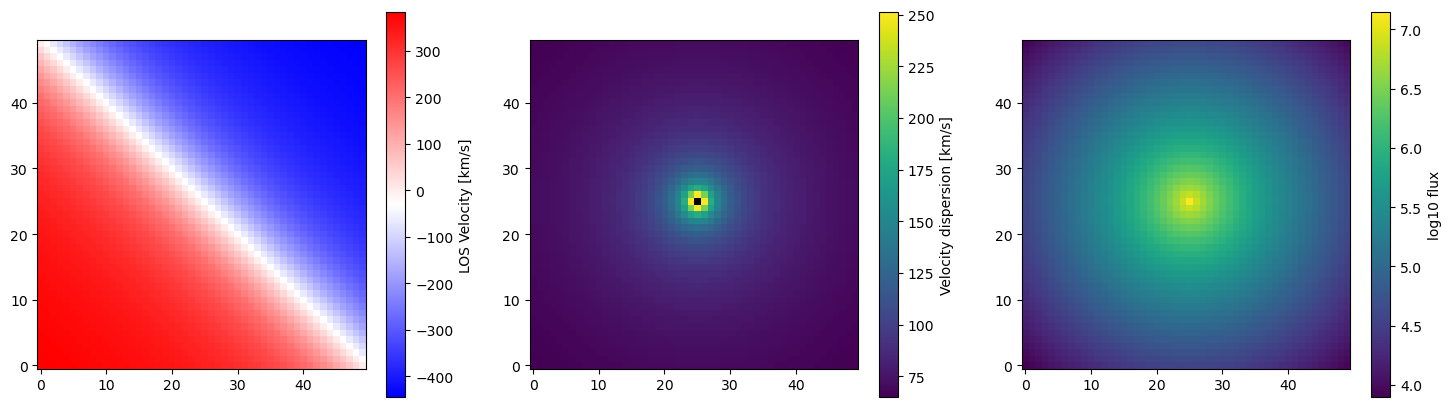

In [6]:
ifulmodel.generate_source_plots(sim_params, image_size=50, dpix=0.01)

## 6. Combine and Generate Lensed Image Plane Plots

Next, we generate the convolved lensed emission line parameters using `generate_residuals(vd_plots=True)`. This creates a three-panel plot showing the convolved line-of-sight velocity map, convolved velocity dispersion map (showing a strong central cusp due to the supermassive black hole component), and lensed flux map.

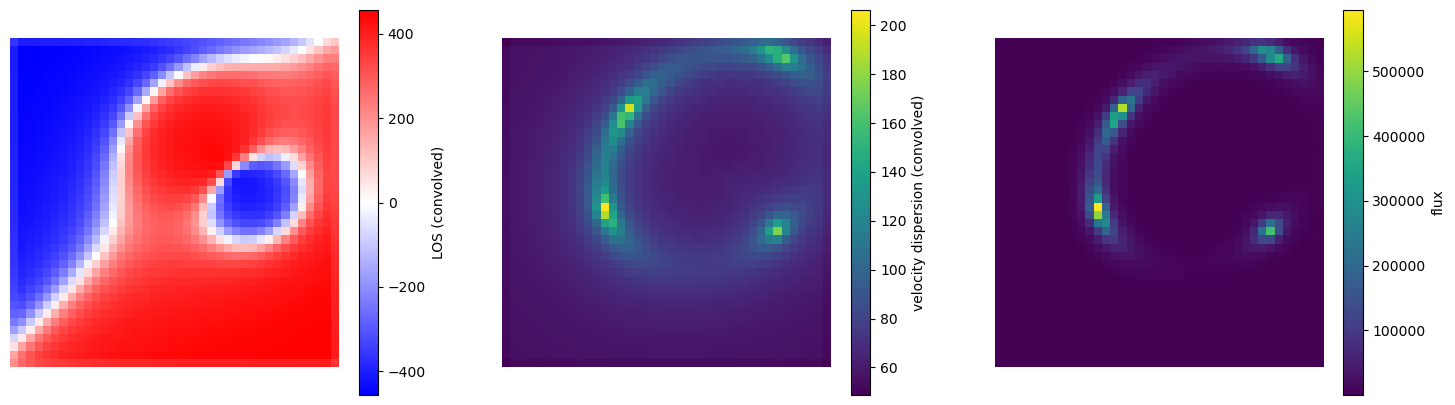

In [7]:
res, simulated_datacube = ifulmodel.generate_residuals(sim_params, return_datacube=True, vd_plots=True)

## 7. Simulate Instrument Noise

We simulate realistic instrumental noise on our model datacube by adding two components:
1. **Background / Readout Noise**: A constant noise floor across all pixels, modeled as Gaussian noise with standard deviation equal to 2% of the peak source flux.
2. **Shot Noise**: Poisson-like noise from the source signal itself, where the standard deviation scales as the square of the local flux. We scale it so that the relative standard deviation at peak flux is 3%.

We plot the clean vs noisy white-light images and compare the spectrum at the peak pixel to show the [OIII] doublet lines with noise.

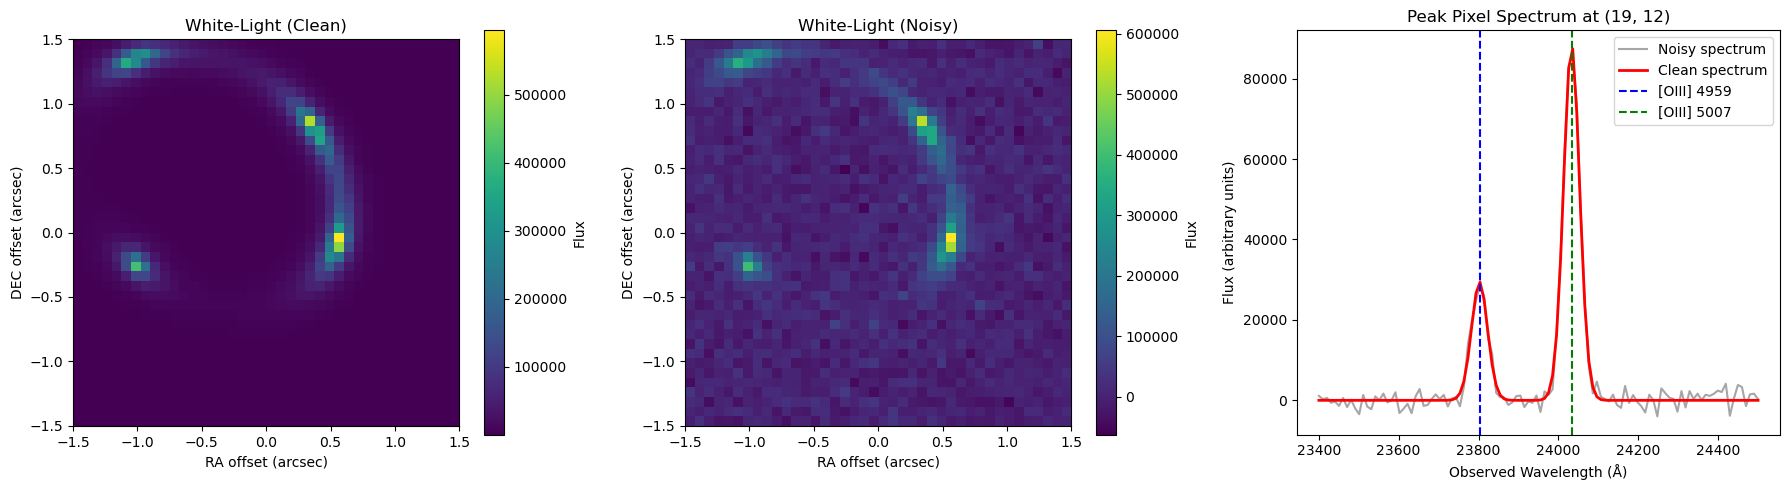

In [8]:
# Add noise to the datacube
np.random.seed(42)  # For reproducibility
peak_flux = np.max(simulated_datacube)
bg_std = 0.02 * peak_flux
bg_noise = np.random.normal(loc=0.0, scale=bg_std, size=simulated_datacube.shape)

simulated_datacube_noisy = simulated_datacube + bg_noise

# Generate white-light images
whitelight_clean = np.nansum(simulated_datacube, axis=0)
whitelight_noisy = np.nansum(simulated_datacube_noisy, axis=0)

# Spectrum of the peak pixel
peak_idx = np.unravel_index(np.argmax(whitelight_clean), whitelight_clean.shape)
spectrum_clean = simulated_datacube[:, peak_idx[0], peak_idx[1]]
spectrum_noisy = simulated_datacube_noisy[:, peak_idx[0], peak_idx[1]]

# Plotting comparison
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Clean white-light
im0 = axs[0].imshow(whitelight_clean, extent=[1.5, -1.5, -1.5, 1.5], origin='lower', cmap='viridis')
axs[0].set_title("White-Light (Clean)")
axs[0].set_xlabel("RA offset (arcsec)")
axs[0].set_ylabel("DEC offset (arcsec)")
fig.colorbar(im0, ax=axs[0], label="Flux")
axs[0].invert_xaxis()  # INVERT X-AXIS FOR RA ALIGNMENT

# Noisy white-light
im1 = axs[1].imshow(whitelight_noisy, extent=[1.5, -1.5, -1.5, 1.5], origin='lower', cmap='viridis')
axs[1].set_title("White-Light (Noisy)")
axs[1].set_xlabel("RA offset (arcsec)")
axs[1].set_ylabel("DEC offset (arcsec)")
fig.colorbar(im1, ax=axs[1], label="Flux")
axs[1].invert_xaxis()  # INVERT X-AXIS FOR RA ALIGNMENT

# Spectrum
wavelength_axis = imset.wavelength
axs[2].plot(wavelength_axis, spectrum_noisy, label="Noisy spectrum", color="gray", alpha=0.7)
axs[2].plot(wavelength_axis, spectrum_clean, label="Clean spectrum", color="red", lw=2)
axs[2].axvline(4959.0 * (1 + 3.8), color="blue", ls="--", label="[OIII] 4959")
axs[2].axvline(5007.0 * (1 + 3.8), color="green", ls="--", label="[OIII] 5007")
axs[2].set_title(f"Peak Pixel Spectrum at ({peak_idx[0]}, {peak_idx[1]})")
axs[2].set_xlabel("Observed Wavelength (Å)")
axs[2].set_ylabel("Flux (arbitrary units)")
axs[2].legend()

plt.tight_layout()


## 8. Save Simulated Datacube as a FITS File

Finally, we save the simulated 3D noisy datacube to a standard FITS file with appropriate WCS keywords in the header.

In [9]:
fits_filename = "simulated_lensed_galaxy_datacube.fits"

# Create Primary HDU using the noisy datacube
hdu = fits.PrimaryHDU(simulated_datacube_noisy)

# Add WCS headers matching NIRSpec IFU dimensions and spectral properties
hdu.header["CTYPE1"] = "RA---TAN"
hdu.header["CTYPE2"] = "DEC--TAN"
hdu.header["CTYPE3"] = "AWAV"
hdu.header["CRPIX1"] = 20.5
hdu.header["CRVAL1"] = 0.0
hdu.header["CDELT1"] = -0.075 / 3600.0
hdu.header["CUNIT1"] = "deg"
hdu.header["CRPIX2"] = 20.5
hdu.header["CRVAL2"] = 0.0
hdu.header["CDELT2"] = 0.075 / 3600.0
hdu.header["CUNIT2"] = "deg"
hdu.header["CRPIX3"] = 1.0
hdu.header["CRVAL3"] = wavelengths[5]  # Starting wavelength before continuum subtraction
hdu.header["CDELT3"] = 10.0
hdu.header["CUNIT3"] = "Angstrom"
hdu.header["EXPTIME"] = 1000.0
hdu.header["REDSHIFT"] = 3.8
hdu.header["COMMENT"] = "Simulated noisy lensed galaxy [OIII] 4959 and 5007 doublet NIRSPEC G235M datacube"

# Save to FITS
hdu.writeto(fits_filename, overwrite=True)
